# PPA EDA

**Goal**: distributions, pack segmentation, elasticity signals, seasonality.

Follows the engineered features built in `src/features.py`; no data is modified here.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None

from src.features import build_features
from src.split import expanding_window_cv, final_holdout_split, describe_folds
from src.config import DATA_PATH, CANDIDATE_FEATURES, CATEGORICAL_COLS

In [2]:
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
df.head()

shape: (92777, 13)


,product_sku_code,customer,year,yearweek,nielsen_total_volume,promotion_indicator,top_brand,flavor_internal,pack_type_internal,pack_size_internal,units_per_package_internal,material_medium_description,price_per_item
0,201050,L2_ASDA,2023,202301,561,0,COCA-COLA,COLA,GLASS,250,4,250MLNRG 6X4P COCA-COLA,3.7458
1,201050,L2_ASDA,2023,202302,442,0,COCA-COLA,COLA,GLASS,250,4,250MLNRG 6X4P COCA-COLA,3.7443
2,201050,L2_ASDA,2023,202303,410,0,COCA-COLA,COLA,GLASS,250,4,250MLNRG 6X4P COCA-COLA,3.7451
3,201050,L2_ASDA,2023,202304,423,0,COCA-COLA,COLA,GLASS,250,4,250MLNRG 6X4P COCA-COLA,3.7484
4,201050,L2_ASDA,2023,202305,427,0,COCA-COLA,COLA,GLASS,250,4,250MLNRG 6X4P COCA-COLA,3.7454


In [3]:
df_fe = build_features(df)
print('after feature engineering:', df_fe.shape)
print('new columns:', [c for c in df_fe.columns if c not in df.columns])


after feature engineering: (92777, 25)
new columns: ['price_per_litre', 'price_per_100ml', 'week', 'week_sin', 'week_cos', 'continuous_week', 'pack_size_total', 'pack_tier', 'log_nielsen_total_volume', 'volume_in_litres', 'log_volume_in_litres', 'log_price_per_litre']


## Target distribution (right-skewed -> log transform mandatory)

Target is `log_volume_in_litres` = log1p(packs * units_per_pack * pack_size_ml / 1000). Litres normalises across pack sizes so cross-SKU pooling and elasticity comparisons are unit-consistent.

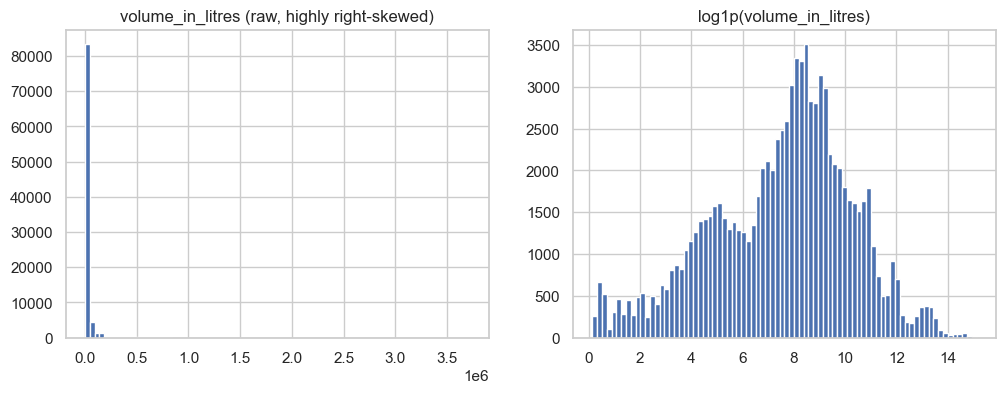

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_fe['volume_in_litres'].hist(bins=80, ax=axes[0])
axes[0].set_title('volume_in_litres (raw, highly right-skewed)')
df_fe['log_volume_in_litres'].hist(bins=80, ax=axes[1])
axes[1].set_title('log1p(volume_in_litres)')
plt.show()

## Time-series CV fold summary

In [5]:
dev_idx, test_idx = final_holdout_split(df_fe)
df_dev = df_fe.iloc[dev_idx].reset_index(drop=True)
print('dev rows:', len(df_dev), '  sealed test rows:', len(test_idx))
describe_folds(df_dev)

dev rows: 73887   sealed test rows: 18890


,fold,train_rows,val_rows,train_cw_min,train_cw_max,val_cw_min,val_cw_max,train_yw_min,train_yw_max,val_yw_min,val_yw_max
0,1,17836,18598,0,28,29,57,202301,202329,202330,202407
1,2,36434,18874,0,57,58,86,202301,202407,202408,202436
2,3,55308,18579,0,86,87,115,202301,202436,202437,202514


## Price-volume scatter by pack tier (elasticity signal)

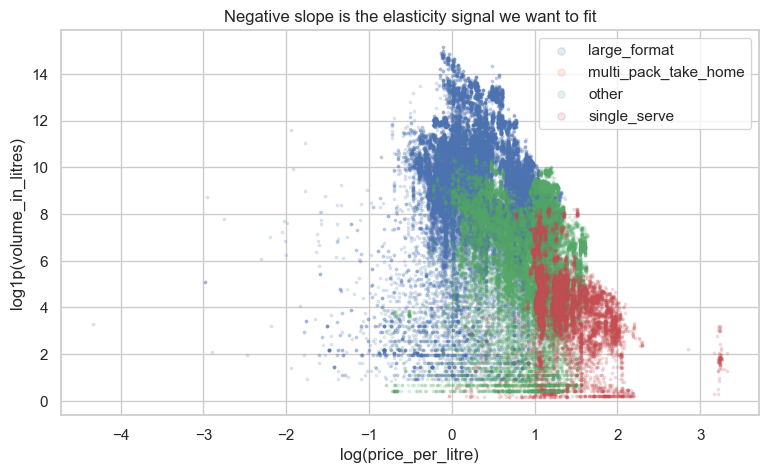

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for tier, sub in df_fe.groupby('pack_tier'):
    ax.scatter(sub['log_price_per_litre'], sub['log_volume_in_litres'], s=3, alpha=0.15, label=tier)
ax.set_xlabel('log(price_per_litre)'); ax.set_ylabel('log1p(volume_in_litres)')
ax.set_title('Negative slope is the elasticity signal we want to fit')
ax.legend(markerscale=3)
plt.show()

## Promo intensity vs volume

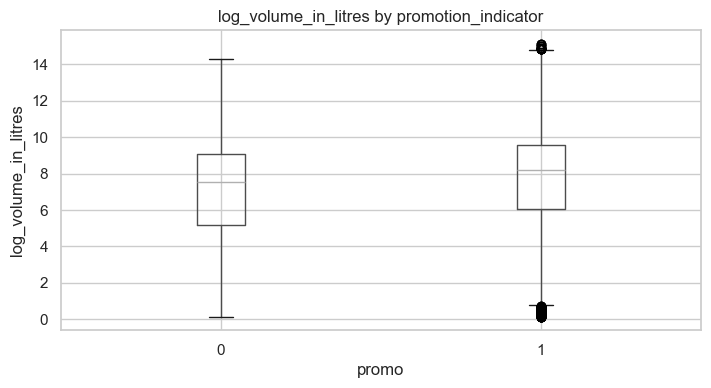

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_fe.boxplot(column='log_volume_in_litres', by='promotion_indicator', ax=ax)
ax.set_title('log_volume_in_litres by promotion_indicator'); ax.set_xlabel('promo'); ax.set_ylabel('log_volume_in_litres')
plt.suptitle('')
plt.show()

## Correlation map (sanity check on collinearity claim)

['product_sku_code', 'customer', 'year', 'yearweek', 'nielsen_total_volume', 'promotion_indicator', 'top_brand', 'flavor_internal', 'pack_type_internal', 'pack_size_internal', 'units_per_package_internal', 'material_medium_description', 'price_per_item', 'price_per_litre', 'price_per_100ml', 'week', 'week_sin', 'week_cos', 'continuous_week', 'pack_size_total', 'pack_tier', 'log_nielsen_total_volume', 'volume_in_litres', 'log_volume_in_litres', 'log_price_per_litre']


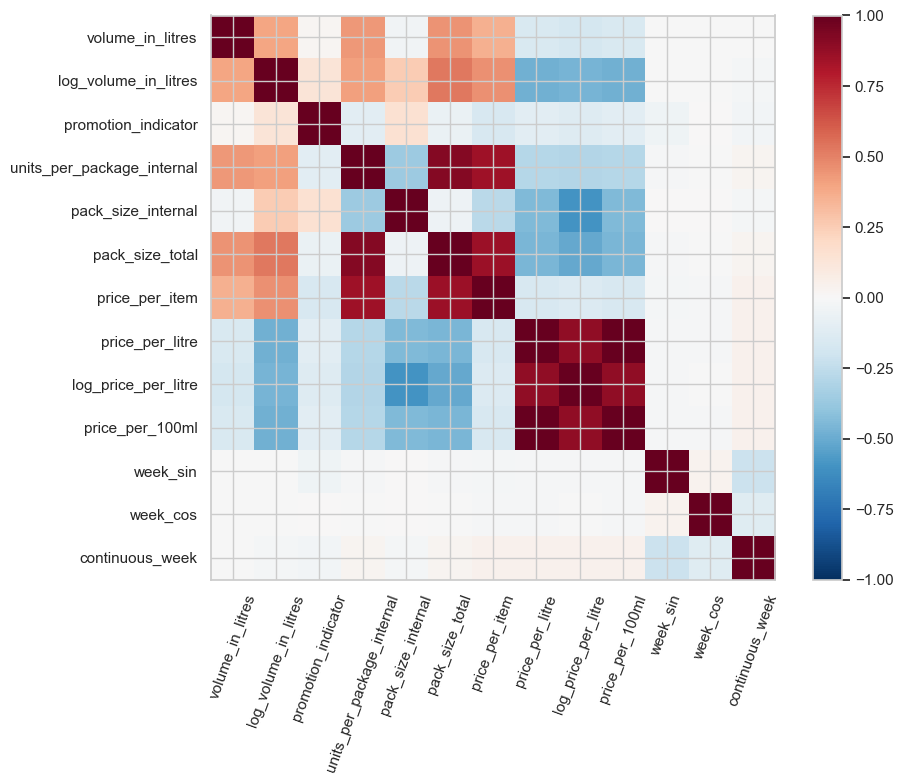

In [8]:
print([c for c in df_fe.columns])
num_cols = [
    'volume_in_litres',
    'log_volume_in_litres',
    'promotion_indicator',
    'units_per_package_internal',
    'pack_size_internal',
    'pack_size_total',
    'price_per_item',
    'price_per_litre',
    'log_price_per_litre',
    'price_per_100ml',
    'week_sin',
    'week_cos',
    'continuous_week',
]
corr = df_fe[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=70)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()